# CIL + FL Task/Round Plots

In [3]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path


In [1]:
log_files = [
    "results_cil/FedAvg_finetune_10client_label_skew_0.1_5.0.log", #baseline
    "results_cil/FedAvg_lwf_10client_label_skew_0.1_5.0_alpha0.99_temp2.0.log",
    "results_cil/FedAvg_ewc_10client_label_skew_0.1_5.0_lambda10.0.log",
    "results_cil/FedAvg_mas_10client_label_skew_0.1_5.0_lambda20.0.log",
    # "results_cil/FedAvg_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0.log",
    # "results_cil/FedAvg_foster_10client_label_skew_0.1_5.0_mem500_b1_0.97_b2_0.97_okd1.0.log",
    # "results_cil/FedAvg_icarl_10client_label_skew_0.1_5.0_mem200_bce0.log",
    #"results_cil/FedAvg_foster_10client_label_skew_0.1_5.0_mem500_b1_0.97_b2_0.97_okd1.0.log",
    "results_cil/FedAvg_icarl_10client_label_skew_0.1_5.0_mem500_bce0.log",
    "results_cil/FedAvg_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0_val0.4.log",
    "results_cil/FedAvg_foster_10client_label_skew_0.1_5.0_mem500_b1_0.97_b2_0.97_okd1.0.log",
    "results_cil/FedAvg_glfc_10client_label_skew_0.1_5.0_mem500_enc50.log",
    "results_cil/FedAvg_cbkd_10client_label_skew_0.1_5.0_lam10.0_a10.0_b10.0.log",
    "results_cil/FedAvg_cbkd_10client_label_skew_0.1_5.0_lam100.0_a1000.0_b10.0.log",
]

# side-by-side
# log_files = [
#     # EWC
#     "results_cil/FedAvg_ewc_10client_label_skew_0.1_5.0_lambda10.0.log",
#     "results_cil/FedSSD_ewc_10client_label_skew_0.1_5.0_lambda10.0_ssd1.0.log",
#     # iCaRL
#     "results_cil/FedAvg_icarl_10client_label_skew_0.1_5.0_mem500_bce0.log",
#     "results_cil/FedSSD_icarl_10client_label_skew_0.1_5.0_mem500_bce0_ssd1.0.log",
#     # BiC
#     "results_cil/FedAvg_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0_val0.4.log",
#     "results_cil/FedSSD_bic_10client_label_skew_0.1_5.0_mem500_alpha0.5_temp2.0_val0.4_ssd1.0.log",
# ]



In [4]:
ansi_re = re.compile(r"\x1b\[[0-9;]*m")
task_re = re.compile(r"^TASK\s+(\d+)")
round_task_re = re.compile(r"^Round\s+(\d+)\s+\|\s+Task\s+(\d+)\s+\|\s+Acc:\s+([\d.]+)\s+\|\s+Loss:\s+([\d.]+)")
final_re = re.compile(r"Final test.*Acc=([\d.]+)\s*\|\s*Loss=([\d.]+)")

def parse_cil_log(path):
    lines = Path(path).read_text().splitlines()
    tasks = defaultdict(lambda: defaultdict(dict))
    task_max_round = defaultdict(int)
    current_task = None
    for raw in lines:
        line = ansi_re.sub("", raw).strip()
        m = task_re.match(line)
        if m:
            current_task = int(m.group(1))
            continue
        m = round_task_re.match(line)
        if m:
            r = int(m.group(1))
            eval_task = int(m.group(2))
            acc = float(m.group(3))
            loss = float(m.group(4))
            tasks[current_task][r][eval_task] = {"acc": acc, "loss": loss}
            if r > task_max_round[current_task]:
                task_max_round[current_task] = r
    task_ids = sorted(tasks.keys())
    offsets = {}
    offset = 0
    for t in task_ids:
        offsets[t] = offset
        offset += task_max_round[t]
    return tasks, task_max_round, offsets

def parse_final_acc(path):
    lines = Path(path).read_text().splitlines()
    for line in reversed(lines):
        line = ansi_re.sub("", line).strip()
        m = final_re.search(line)
        if m:
            return float(m.group(1)), float(m.group(2))
    return None, None

def build_per_task_series(tasks, task_max_round, offsets):
    series = defaultdict(lambda: {"x": [], "y": []})
    for task_id in sorted(tasks.keys()):
        for r in range(1, task_max_round[task_id] + 1):
            evals = tasks[task_id].get(r, {})
            for eval_task, vals in evals.items():
                abs_r = offsets[task_id] + r
                series[eval_task]["x"].append(abs_r)
                series[eval_task]["y"].append(vals["acc"])
    return series

def build_old_new_series(tasks, task_max_round, offsets):
    xs = []
    new_acc = []
    old_acc = []
    new_loss = []
    old_loss = []
    for task_id in sorted(tasks.keys()):
        for r in range(1, task_max_round[task_id] + 1):
            evals = tasks[task_id].get(r, {})
            abs_r = offsets[task_id] + r
            xs.append(abs_r)
            cur = evals.get(task_id)
            new_acc.append(cur["acc"] if cur else np.nan)
            new_loss.append(cur["loss"] if cur else np.nan)
            old_vals = [v for k, v in evals.items() if k < task_id]
            if old_vals:
                old_acc.append(np.mean([v["acc"] for v in old_vals]))
                old_loss.append(np.mean([v["loss"] for v in old_vals]))
            else:
                old_acc.append(np.nan)
                old_loss.append(np.nan)
    return xs, new_acc, old_acc, new_loss, old_loss

def task_spans(task_max_round, offsets):
    spans = []
    for t in sorted(task_max_round.keys()):
        start = offsets[t] + 1
        end = offsets[t] + task_max_round[t]
        spans.append((t, start, end))
    return spans

mem_re = re.compile(r"mem(\d+)")
alpha_re = re.compile(r"alpha([\d.]+)")
lambda_re = re.compile(r"lambda([\d.]+)")
val_re = re.compile(r"val([\d.]+)")

def parse_name(path):
    name = Path(path).stem
    parts = name.split("_")
    fl = parts[0] if parts else ""
    cil = parts[1] if len(parts) > 1 else ""
    client = ""
    partition = ""
    for p in parts:
        if p.endswith("client"):
            client = p
        if p in ["label", "label-skew", "label_skew", "iid"]:
            partition = p
    partition = partition.replace("label", "label skew")
    lam_m = lambda_re.search(name)
    mem_m = mem_re.search(name)
    alpha_m = alpha_re.search(name)
    val_m = val_re.search(name)
    extras = []
    if lam_m:
        extras.append(f"λ={lam_m.group(1)}")
    if mem_m:
        extras.append(f"mem={mem_m.group(1)}")
    if alpha_m:
        extras.append(f"α={alpha_m.group(1)}")
    if val_m:
        extras.append(f"val={val_m.group(1)}")
    tag = f" ({', '.join(extras)})" if extras else ""
    return f"{fl} {cil}{tag} - {client} {partition}"

## Part 1 — Per-task accuracy over rounds (one plot per log)

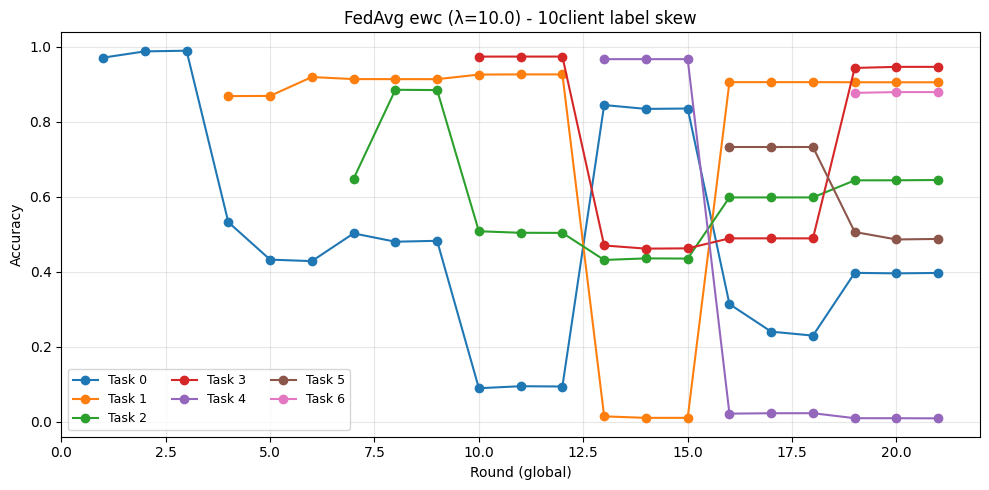

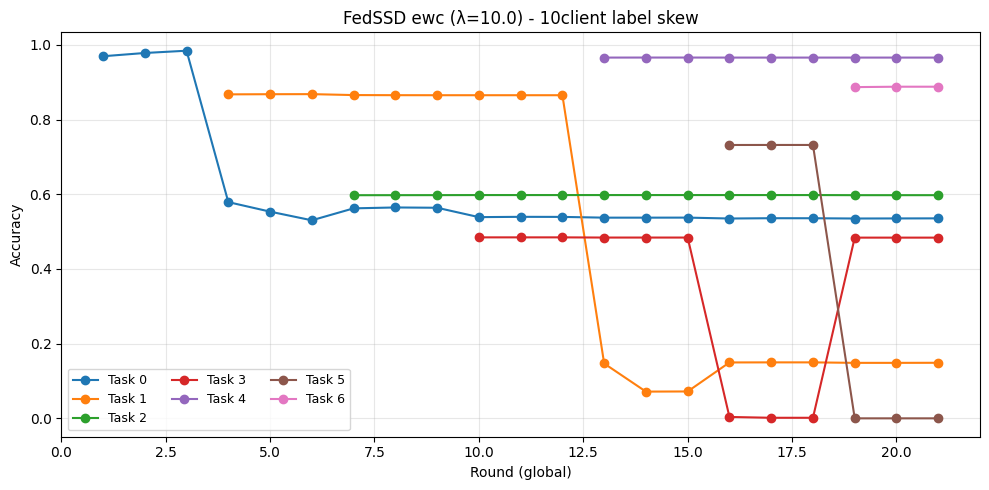

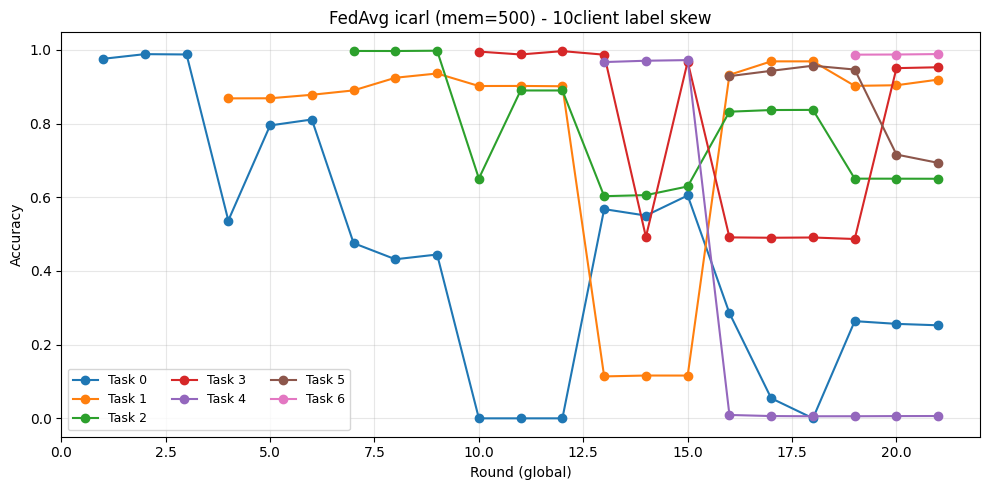

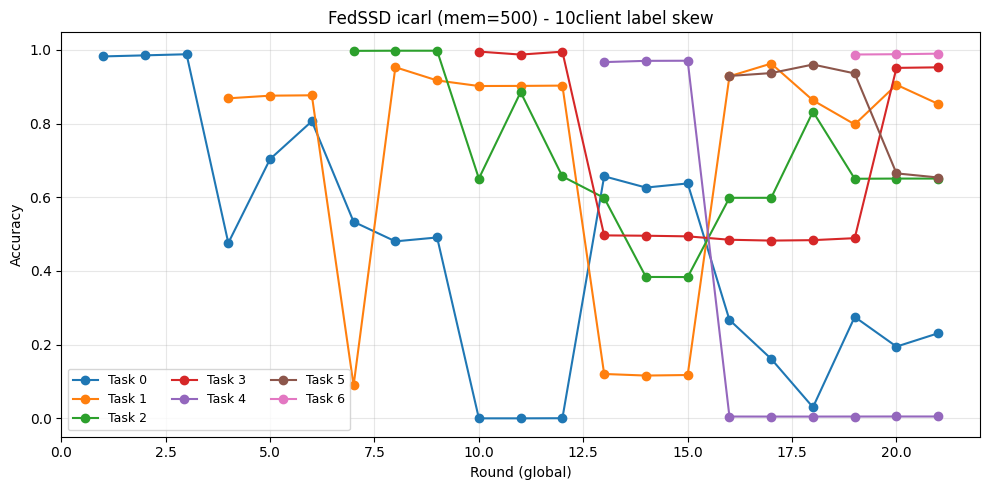

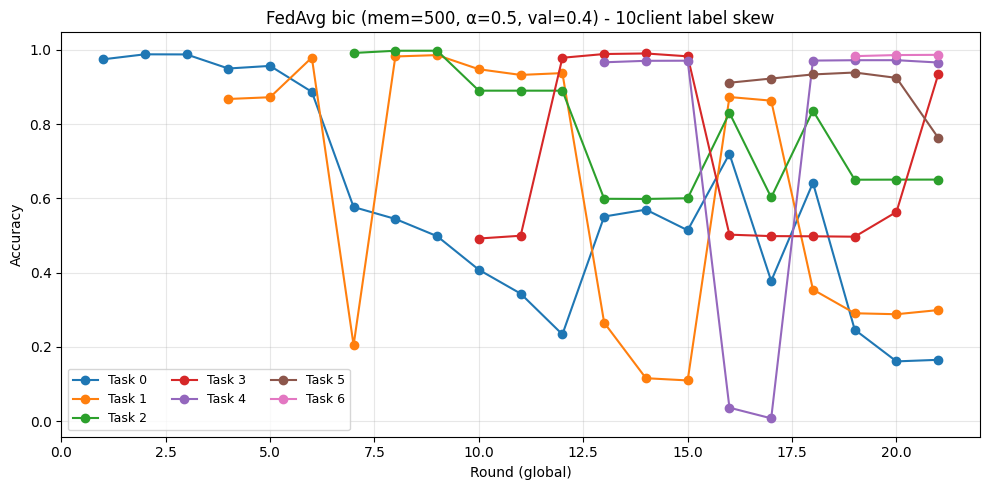

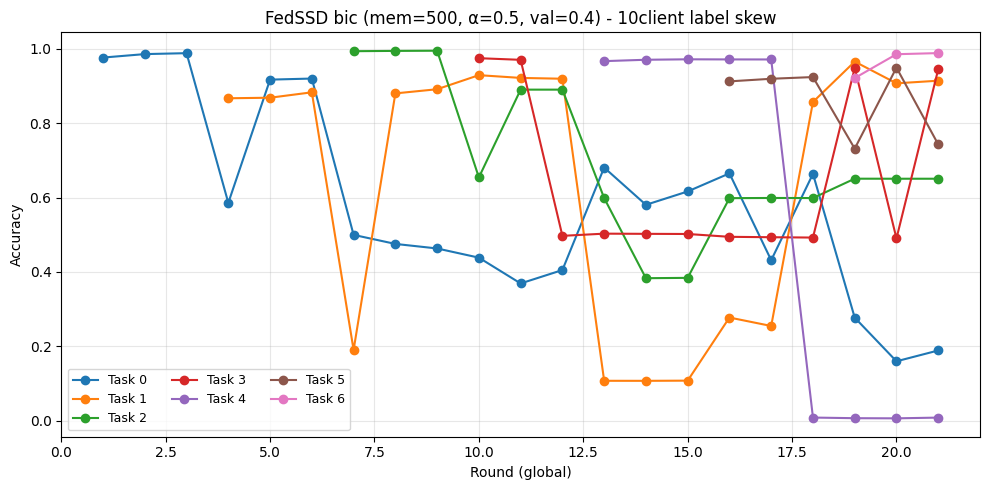

In [15]:
for path in log_files:
    tasks, task_max_round, offsets = parse_cil_log(path)
    series = build_per_task_series(tasks, task_max_round, offsets)
    plt.figure(figsize=(10, 5))
    for task_id, data in series.items():
        plt.plot(data["x"], data["y"], marker='o', label=f"Task {task_id}")
    plt.title(parse_name(path))
    plt.xlabel("Round (global)")
    plt.ylabel("Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


## Part 2 — Per-task accuracy heatmap

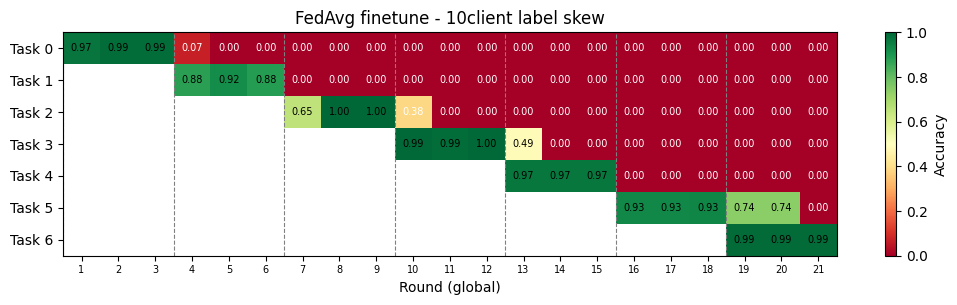

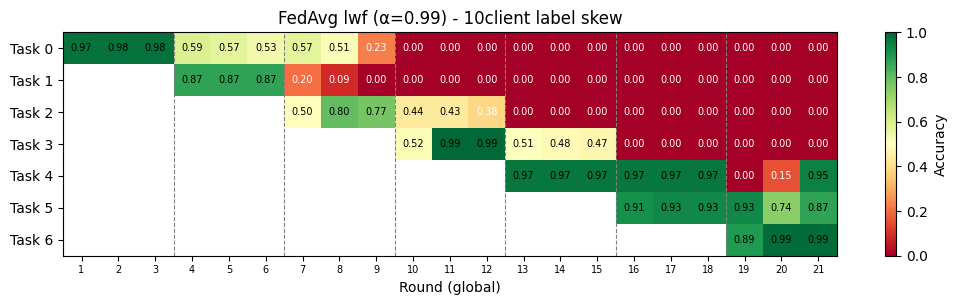

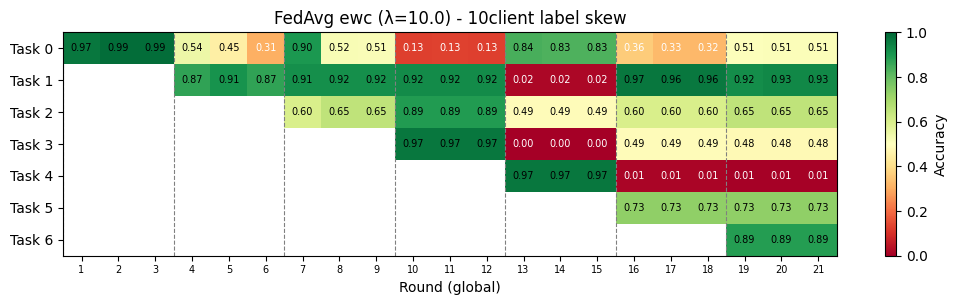

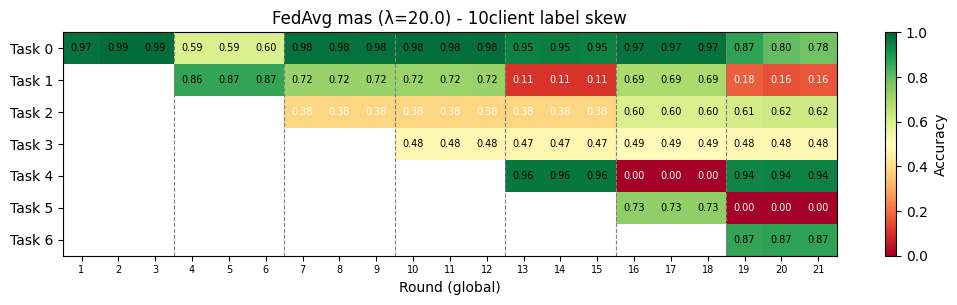

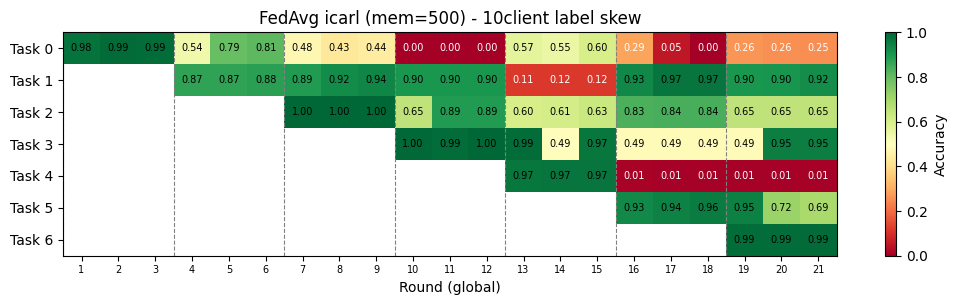

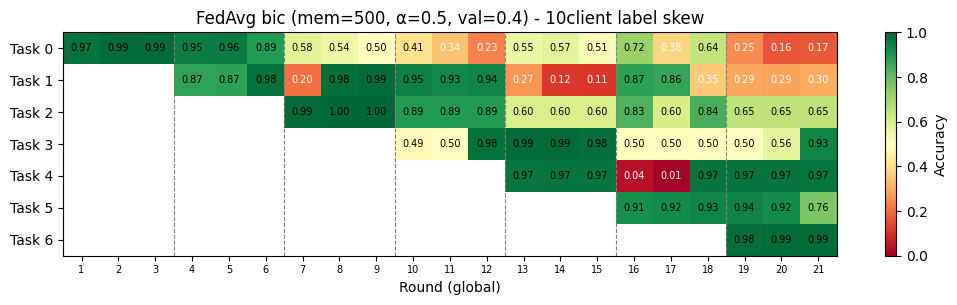

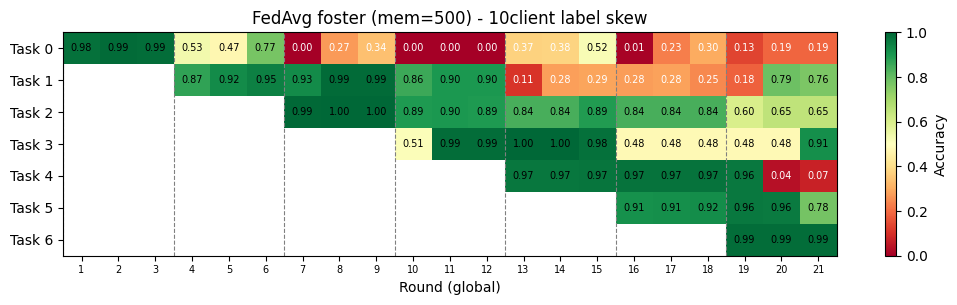

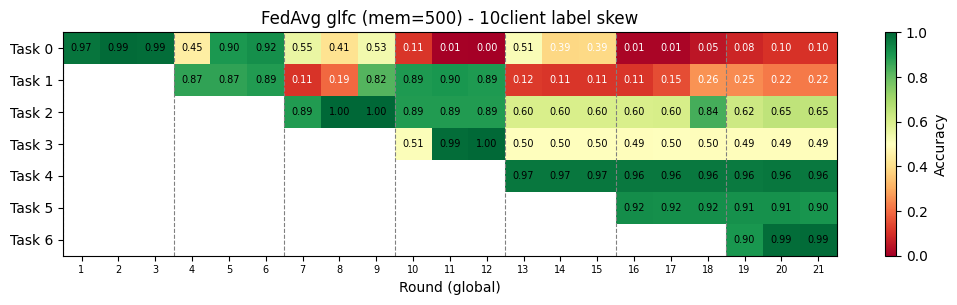

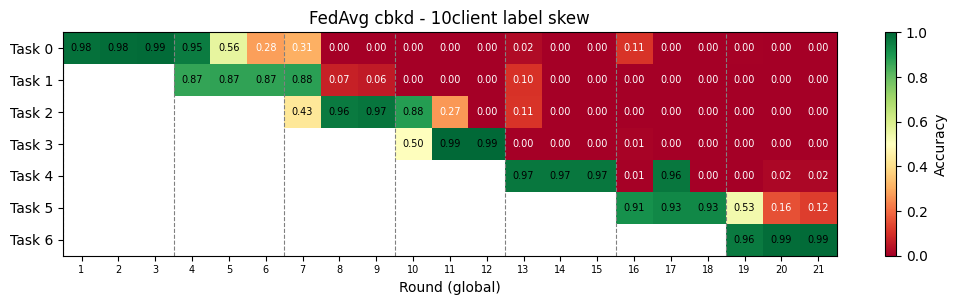

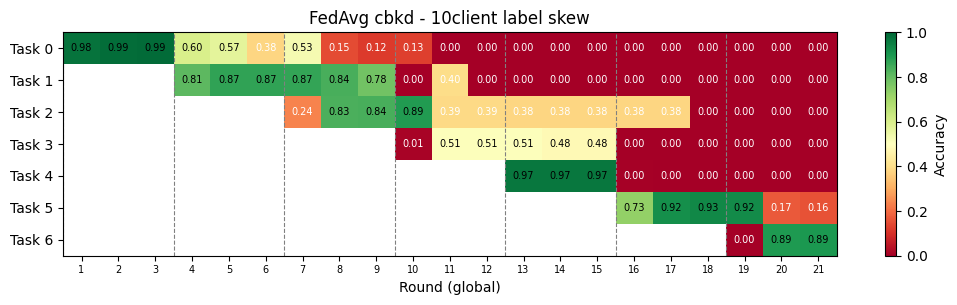

In [5]:
for path in log_files:
    tasks, task_max_round, offsets = parse_cil_log(path)
    all_eval_tasks = sorted({et for t in tasks for r in tasks[t] for et in tasks[t][r]})
    total_rounds = max(offsets[t] + task_max_round[t] for t in tasks)
    grid = np.full((len(all_eval_tasks), total_rounds), np.nan)
    task_idx = {t: i for i, t in enumerate(all_eval_tasks)}
    for train_task in sorted(tasks):
        for r in range(1, task_max_round[train_task] + 1):
            col = offsets[train_task] + r - 1
            for et, vals in tasks[train_task][r].items():
                grid[task_idx[et], col] = vals["acc"]

    fig, ax = plt.subplots(figsize=(max(8, total_rounds * 0.5), max(3, len(all_eval_tasks) * 0.45)))
    im = ax.imshow(grid, aspect='auto', vmin=0, vmax=1, cmap='RdYlGn', interpolation='nearest')
    ax.set_yticks(range(len(all_eval_tasks)))
    ax.set_yticklabels([f"Task {t}" for t in all_eval_tasks])
    ax.set_xticks(range(total_rounds))
    ax.set_xticklabels(range(1, total_rounds + 1), fontsize=7)
    ax.set_xlabel("Round (global)")
    ax.set_title(parse_name(path))
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid[i, j]
            if not np.isnan(v):
                color = "white" if v < 0.4 else "black"
                ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=7, color=color)
    spans = task_spans(task_max_round, offsets)
    for t, start, end in spans:
        ax.axvline(start - 1.5, color='grey', linewidth=0.8, linestyle='--')
    fig.colorbar(im, ax=ax, label="Accuracy")
    plt.tight_layout()
    plt.show()

## Final accuracy comparison (bar chart)

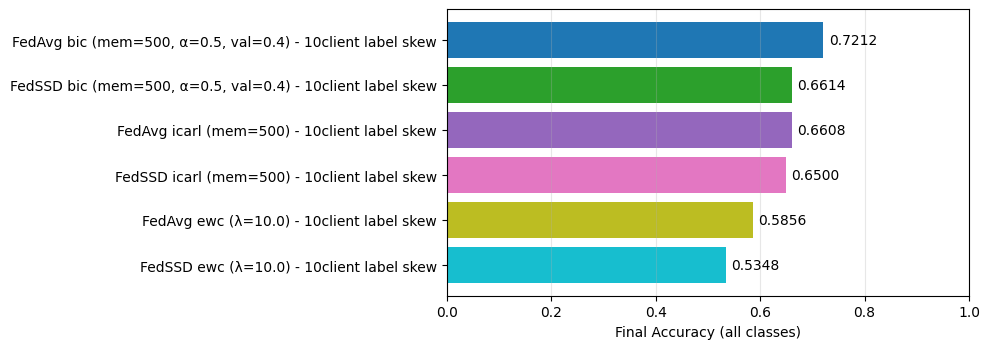

In [18]:
names, accs = [], []
for path in log_files:
    acc, loss = parse_final_acc(path)
    if acc is not None:
        names.append(parse_name(path))
        accs.append(acc)

order = np.argsort(accs)[::-1]
names = [names[i] for i in order]
accs = [accs[i] for i in order]

fig, ax = plt.subplots(figsize=(10, max(3, len(names) * 0.6)))
bars = ax.barh(range(len(names)), accs, color=plt.cm.tab10(np.linspace(0, 1, len(names))))
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Final Accuracy (all classes)")
ax.set_xlim(0, 1)
for bar, v in zip(bars, accs):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.4f}", va='center')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()